In [ ]:
!pip install tcia_utils --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.3 MB/s eta 0:00:00


In [ ]:
import importlib
import tcia_utils
#!pip show tcia_utils
from tcia_utils import nbia

# In 3.x, public collections need no auth — just test connectivity
collections = nbia.getCollections()
print(type(collections))
print(collections[:5] if collections else "None — network issue")

<class 'list'>
[{'Collection': '4D-Lung'}, {'Collection': 'A091105'}, {'Collection': 'ACNS0332'}, {'Collection': 'ACRIN-6698'}, {'Collection': 'ACRIN-Contralateral-Breast-MR'}]


In [ ]:
# Search for anything lymphoma-related
lymphoma_collections = [c for c in collections if 'lymph' in str(c).lower() or 'DLBC' in str(c)]
print(lymphoma_collections)


[{'Collection': 'CT Lymph Nodes'}, {'Collection': 'Mediastinal-Lymph-Node-SEG'}]


In [7]:
#Step 1 — Test connectivity and find Hodgkin Lymphoma slides:
import requests
import pandas as pd

endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.disease_type",
                "value": "Hodgkin Lymphoma"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Slide Image"
            }
        }
    ]
}

params = {
    "filters": str(filters).replace("'", '"'),
    "fields": "file_id,file_name,data_format,cases.disease_type,cases.project.project_id,cases.samples.sample_type",
    "format": "JSON",
    "size": 10
}

response = requests.get(endpoint, params=params)
data = response.json()
print(f"Status: {response.status_code}")
print(f"Total files found: {data['data']['pagination']['total']}")
pd.DataFrame([h['id'] and h for h in data['data']['hits']])

Status: 200
Total files found: 0


""


In [8]:
#Step 1 — See all available disease types to find the exact string:
import requests
import json

endpoint = "https://api.gdc.cancer.gov/cases"

params = {
    "facets": "disease_type",
    "size": 0,
    "format": "JSON"
}

response = requests.get(endpoint, params=params)
buckets = response.json()["data"]["aggregations"]["disease_type"]["buckets"]

# Print all disease types containing "lymph" or "hodgkin"
for b in buckets:
    if any(x in b["key"].lower() for x in ["lymph", "hodgkin", "DLBCL"]):
        print(f"{b['key']}: {b['doc_count']} cases")

lymphoid leukemias: 2204 cases
acute lymphoblastic leukemia: 1086 cases
mature b-cell lymphomas: 977 cases
mature t- and nk-cell lymphomas: 62 cases
malignant lymphomas, nos or diffuse: 3 cases


In [9]:
import requests
import json

endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.disease_type",
                "value": [
                    "Lymphoid Leukemias",
                    "Acute Lymphoblastic Leukemia",
                    "Mature B-Cell Lymphomas",
                    "Malignant Lymphomas, NOS or Diffuse"
                ]
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Slide Image"
            }
        }
    ]
}

params = {
    "filters": json.dumps(filters),
    "facets": "cases.disease_type,data_format",
    "size": 0,
    "format": "JSON"
}

response = requests.get(endpoint, params=params)
data = response.json()

print(f"Total slide files: {data['data']['pagination']['total']}")
print("\nBreakdown by disease type:")
for b in data["data"]["aggregations"]["cases.disease_type"]["buckets"]:
    print(f"  {b['key']}: {b['doc_count']}")

print("\nBreakdown by format:")
for b in data["data"]["aggregations"]["data_format"]["buckets"]:
    print(f"  {b['key']}: {b['doc_count']}")

Total slide files: 2609

Breakdown by disease type:
  adenomas and adenocarcinomas: 12565
  squamous cell neoplasms: 4115
  gliomas: 3704
  ductal and lobular neoplasms: 3670
  mature b-cell lymphomas: 2609
  cystic, mucinous and serous neoplasms: 2322
  not reported: 1366
  nevi and melanomas: 1147
  transitional cell papillomas and carcinomas: 933
  germ cell neoplasms: 664
  acinar cell neoplasms: 601
  paragangliomas and glomus tumors: 389
  thymic epithelial neoplasms: 318
  myomatous neoplasms: 284
  fibromatous neoplasms: 238
  mesothelial neoplasms: 175
  complex mixed and stromal neoplasms: 165
  soft tissue tumors and sarcomas, nos: 165
  lipomatous neoplasms: 159
  epithelial neoplasms, nos: 120
  neoplasms, nos: 81
  complex epithelial neoplasms: 65
  nerve sheath tumors: 37
  synovial-like neoplasms: 30
  adnexal and skin appendage neoplasms: 4
  basal cell neoplasms: 4
  fibroepithelial neoplasms: 4
  _missing: 6

Breakdown by format:
  svs: 2422
  jpeg 2000: 187


In [10]:
import requests
import json
import pandas as pd

endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.disease_type",
                "value": "Mature B-Cell Lymphomas"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Slide Image"
            }
        }
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id,file_name,data_format,file_size,cases.disease_type,cases.project.project_id,cases.case_id,cases.diagnoses.primary_diagnosis",
    "format": "JSON",
    "size": 3000
}

response = requests.get(endpoint, params=params)
hits = response.json()["data"]["hits"]

rows = []
for h in hits:
    case = h.get("cases", [{}])[0]
    diagnosis = case.get("diagnoses", [{}])[0].get("primary_diagnosis", "unknown")
    rows.append({
        "file_id": h.get("file_id"),
        "file_name": h.get("file_name"),
        "data_format": h.get("data_format"),
        "file_size_mb": round(h.get("file_size", 0) / 1e6, 1),
        "project": case.get("project", {}).get("project_id"),
        "case_id": case.get("case_id"),
        "primary_diagnosis": diagnosis
    })

df = pd.DataFrame(rows)
print(f"Total slides: {len(df)}")
print(f"\nBreakdown by project:")
print(df["project"].value_counts())
print(f"\nBreakdown by primary diagnosis:")
print(df["primary_diagnosis"].value_counts().head(15))
print(f"\nBreakdown by format:")
print(df["data_format"].value_counts())

Total slides: 2609

Breakdown by project:
project
CGCI-BLGSP          2010
CGCI-HTMCP-DLBCL     496
TCGA-DLBC            103
Name: count, dtype: int64

Breakdown by primary diagnosis:
primary_diagnosis
Burkitt lymphoma, NOS (Includes all variants)                                                                             1809
Diffuse large B-cell lymphoma, NOS                                                                                         523
Burkitt-like lymphoma                                                                                                      131
Not Reported                                                                                                                63
Tumor, NOS                                                                                                                  20
Primary diffuse large B-cell lymphoma of the CNS                                                                            18
B-cell lymphoma, unclassifiable, wit

In [11]:
from tcia_utils import nbia
import pandas as pd

# Get all collections and search for hodgkin/lymphoma related ones
collections = nbia.getCollections()

# Print all collections as a flat list to search manually
if isinstance(collections, list):
    # Handle both list of strings and list of dicts
    if len(collections) > 0 and isinstance(collections[0], dict):
        names = [list(c.values())[0] for c in collections]
    else:
        names = collections

    lymphoma_related = [n for n in names if any(
        x in str(n).lower() for x in ["lymph", "hodgkin", "dlbc", "dlbcl"]
    )]
    print("Lymphoma-related collections:")
    for n in lymphoma_related:
        print(f"  {n}")

    print(f"\nAll collections ({len(names)} total):")
    for n in sorted(names):
        print(f"  {n}")

Lymphoma-related collections:
  CT Lymph Nodes
  Mediastinal-Lymph-Node-SEG

All collections (154 total):
  4D-Lung
  A091105
  ACNS0332
  ACRIN-6698
  ACRIN-Contralateral-Breast-MR
  ACRIN-FLT-Breast
  ACRIN-HNSCC-FDG-PET-CT
  ACRIN-NSCLC-FDG-PET
  AHEP0731
  AHOD0831
  ARAR0331
  AREN0532
  AREN0533
  AREN0534
  Adrenal-ACC-Ki67-Seg
  Advanced-MRI-Breast-Lesions
  Anti-PD-1_Lung
  B-mode-and-CEUS-Liver
  BREAST-DIAGNOSIS
  Breast-Cancer-Screening-DBT
  Breast-MRI-NACT-Pilot
  C4KC-KiTS
  CALGB50303
  CBIS-DDSM
  CC-Radiomics-Phantom
  CC-Radiomics-Phantom-2
  CC-Radiomics-Phantom-3
  CC-Tumor-Heterogeneity
  CMB-AML
  CMB-BRCA
  CMB-CRC
  CMB-GEC
  CMB-LCA
  CMB-MEL
  CMB-MML
  CMB-OV
  CMB-PCA
  CMMD
  COVID-19-AR
  COVID-19-NY-SBU
  CPTAC-AML
  CPTAC-CCRCC
  CPTAC-CM
  CPTAC-LSCC
  CPTAC-LUAD
  CPTAC-PDA
  CPTAC-SAR
  CPTAC-STAD
  CPTAC-UCEC
  CT COLONOGRAPHY
  CT Lymph Nodes
  CT-Phantom4Radiomics
  CT-vs-PET-Ventilation-Imaging
  CT4Harmonization-Multicentric
  CTpred-Sunitinib-p

We couldnt find any hl slides on tcga

In [12]:
## let's see what clinical and annotation metadata GDC has for those 103 TCGA-DLBC slides. Run this:
#Step 1 — Pull detailed metadata for TCGA-DLBC slides:
import requests
import json
import pandas as pd

endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.project.project_id",
                "value": "TCGA-DLBC"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Slide Image"
            }
        }
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": ",".join([
        "file_id",
        "file_name",
        "data_format",
        "file_size",
        "cases.case_id",
        "cases.diagnoses.primary_diagnosis",
        "cases.diagnoses.morphology",
        "cases.diagnoses.tissue_or_organ_of_origin",
        "cases.diagnoses.classification_of_tumor",
        "cases.samples.sample_type",
        "cases.samples.portions.slides.section_location",
        "cases.samples.portions.slides.percent_tumor_cells",
        "cases.samples.portions.slides.percent_necrosis",
        "cases.samples.portions.slides.number_proliferating_cells"
    ]),
    "format": "JSON",
    "size": 200
}

response = requests.get(endpoint, params=params)
hits = response.json()["data"]["hits"]

rows = []
for h in hits:
    case = h.get("cases", [{}])[0]
    diagnosis = case.get("diagnoses", [{}])[0]
    sample = case.get("samples", [{}])[0]
    portion = sample.get("portions", [{}])[0]
    slide = portion.get("slides", [{}])[0]

    rows.append({
        "file_id": h.get("file_id"),
        "file_name": h.get("file_name"),
        "data_format": h.get("data_format"),
        "file_size_mb": round(h.get("file_size", 0) / 1e6, 1),
        "case_id": case.get("case_id"),
        "primary_diagnosis": diagnosis.get("primary_diagnosis"),
        "morphology": diagnosis.get("morphology"),
        "tissue_origin": diagnosis.get("tissue_or_organ_of_origin"),
        "tumor_classification": diagnosis.get("classification_of_tumor"),
        "sample_type": sample.get("sample_type"),
        "section_location": slide.get("section_location"),
        "percent_tumor_cells": slide.get("percent_tumor_cells"),
        "percent_necrosis": slide.get("percent_necrosis"),
        "num_proliferating_cells": slide.get("number_proliferating_cells"),
    })

df_dlbc = pd.DataFrame(rows)
print(f"Total TCGA-DLBC slides: {len(df_dlbc)}")
print(f"\nPrimary diagnoses:")
print(df_dlbc["primary_diagnosis"].value_counts())
print(f"\nMorphology codes:")
print(df_dlbc["morphology"].value_counts())
print(f"\nSample types:")
print(df_dlbc["sample_type"].value_counts())
print(f"\nSection locations:")
print(df_dlbc["section_location"].value_counts())
print(f"\nSlides with tumor cell % annotated: {df_dlbc['percent_tumor_cells'].notna().sum()}")
display(df_dlbc.head(10))

Total TCGA-DLBC slides: 103

Primary diagnoses:
primary_diagnosis
Diffuse large B-cell lymphoma, NOS                  82
Mediastinal (thymic) large B-cell lymphoma           9
Not Reported                                         6
Primary diffuse large B-cell lymphoma of the CNS     6
Name: count, dtype: int64

Morphology codes:
morphology
9680/3          97
Not Reported     6
Name: count, dtype: int64

Sample types:
sample_type
Primary Tumor    103
Name: count, dtype: int64

Section locations:
section_location
Not Reported    44
TOP             41
BOTTOM          18
Name: count, dtype: int64

Slides with tumor cell % annotated: 57


,file_id,file_name,data_format,file_size_mb,case_id,primary_diagnosis,morphology,tissue_origin,tumor_classification,sample_type,section_location,percent_tumor_cells,percent_necrosis,num_proliferating_cells
0,fab9039a-7776-4420-af7f-cb861cf45bf4,TCGA-GS-A9TU-01Z-00-DX1.F10984B9-F06A-4729-B66...,SVS,633.0,1ea575f1-f731-408b-a629-f5f4abab569e,"Diffuse large B-cell lymphoma, NOS",9680/3,Lymph nodes of inguinal region or leg,primary,Primary Tumor,Not Reported,NaN,NaN,None
1,350e86fe-3b45-4503-8f0d-a39269e1864e,TCGA-FF-8047-01A-01-BS1.26a2166c-ed0c-4bac-9cc...,SVS,180.5,f978cb0f-d319-4c01-b4c5-23ae1403a106,"Diffuse large B-cell lymphoma, NOS",9680/3,"Lymph nodes of head, face and neck",primary,Primary Tumor,BOTTOM,100.0,0.0,None
2,4ad5bb7a-626a-4e32-9560-f2c12930e52d,TCGA-GS-A9TY-01A-01-TS1.11C3E54D-DCED-4F22-BA0...,SVS,390.8,6e9437f0-a4ed-475c-ab0e-bf1431c70a90,"Diffuse large B-cell lymphoma, NOS",9680/3,Lymph nodes of axilla or arm,primary,Primary Tumor,TOP,90.0,0.0,None
3,0609ae18-458a-4971-938e-1942e35c11b2,TCGA-FF-8047-01Z-00-DX1.75aa745c-bbe3-4869-a37...,SVS,291.5,f978cb0f-d319-4c01-b4c5-23ae1403a106,"Diffuse large B-cell lymphoma, NOS",9680/3,"Lymph nodes of head, face and neck",primary,Primary Tumor,Not Reported,NaN,NaN,None
4,bad9afb2-fbde-49a0-b05f-ac0fc6b7b57c,TCGA-FF-8047-01A-01-TS1.b9b7d82b-14a3-45a5-954...,SVS,134.2,f978cb0f-d319-4c01-b4c5-23ae1403a106,"Diffuse large B-cell lymphoma, NOS",9680/3,"Lymph nodes of head, face and neck",primary,Primary Tumor,BOTTOM,100.0,0.0,None
5,2f2ae127-0a3d-46b6-8485-ec54d30ff8c3,TCGA-FA-A86F-01Z-00-DX1.EE36DC3F-7539-41E8-ADF...,SVS,753.7,b56bdbdb-43af-4a03-a072-54dd22d7550c,"Diffuse large B-cell lymphoma, NOS",9680/3,Lymph nodes of axilla or arm,primary,Primary Tumor,Not Reported,NaN,NaN,None
6,233e0ac3-e8a6-4132-b4cd-68ddcd3890bd,TCGA-GS-A9TZ-01A-01-TSA.686AE713-E246-41CE-811...,SVS,219.5,eda9496e-be80-4a13-bf06-89f0cc9e937f,Mediastinal (thymic) large B-cell lymphoma,9680/3,"Lymph nodes of head, face and neck",primary,Primary Tumor,TOP,95.0,0.0,None
7,38473a15-36fb-4d50-ad85-a652a27ccc81,TCGA-GS-A9U3-01A-01-TS1.F04D39B6-782C-4903-91E...,SVS,699.4,fdecb74f-ac4e-46b1-b23a-5f7fde96ef9f,"Diffuse large B-cell lymphoma, NOS",9680/3,Lymph nodes of inguinal region or leg,primary,Primary Tumor,TOP,95.0,0.0,None
8,61efcba0-6d35-42c3-8093-5e25b1003fc3,TCGA-G8-6906-01Z-00-DX1.61bfad6c-4e24-414f-9bc...,SVS,1030.7,3f5a897d-1eaa-4d4c-8324-27ac07c90927,Not Reported,Not Reported,Not Reported,not reported,Primary Tumor,Not Reported,NaN,NaN,None
9,1bf116f8-d991-4ca9-b7db-c3c644554335,TCGA-G8-6906-01A-01-BS1.dea2d8e9-4a29-4783-916...,SVS,106.4,3f5a897d-1eaa-4d4c-8324-27ac07c90927,Not Reported,Not Reported,Not Reported,not reported,Primary Tumor,TOP,100.0,0.0,None


**Phase 1 — Burkitt vs DLBCL WSI Classifier**

Download a manageable subset of SVS slides from GDC to Google Drive.


Tile WSIs into 256×256 patches using openslide


Train a ResNet18 patch classifier with PyTorch


Aggregate patch predictions to slide-level

**Phase 2 — Reed-Sternberg Cell Detector**

Source a pre-annotated RS cell patch dataset


Fine-tune a ResNet or small detector on those patches

In [1]:
## phase 1
# Step 1 — Mount Drive (all downloads will go here to survive session resets)
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = "/content/drive/MyDrive/lymphoma_classifier"
os.makedirs(f"{BASE_DIR}/slides/burkitt", exist_ok=True)
os.makedirs(f"{BASE_DIR}/slides/dlbcl", exist_ok=True)
os.makedirs(f"{BASE_DIR}/patches/burkitt", exist_ok=True)
os.makedirs(f"{BASE_DIR}/patches/dlbcl", exist_ok=True)
print("Directory structure ready.")

Mounted at /content/drive
Directory structure ready.


In [2]:
#Tile WSIs into 256×256 patches using openslide
# Step 2 — Install dependencies
!pip install openslide-python -q
!apt-get install -y openslide-tools -q
!pip install requests tqdm -q
print("Done.")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 1s (124 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Selecting previously unselected package openslide-tools.
Preparing to un

In [3]:
# Step 3 — Build a balanced download manifest
# We'll use 50 slides per class to stay within Colab disk limits
import requests, json, pandas as pd

endpoint = "https://api.gdc.cancer.gov/files"

def get_slides(diagnosis_value, project, n=50):
    filters = {
        "op": "and",
        "content": [
            {"op": "=", "content": {"field": "cases.disease_type", "value": "Mature B-Cell Lymphomas"}},
            {"op": "=", "content": {"field": "data_type", "value": "Slide Image"}},
            {"op": "=", "content": {"field": "cases.project.project_id", "value": project}},
            {"op": "=", "content": {"field": "data_format", "value": "SVS"}},
            {"op": "=", "content": {"field": "cases.diagnoses.primary_diagnosis", "value": diagnosis_value}}
        ]
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,file_name,file_size,cases.diagnoses.primary_diagnosis",
        "format": "JSON",
        "size": n
    }
    #here we call the server at GDC
    hits = requests.get(endpoint, params=params).json()["data"]["hits"]
    rows = []
    for h in hits:
        rows.append({
            "file_id": h["file_id"],
            "file_name": h["file_name"],
            "file_size_mb": round(h.get("file_size", 0) / 1e6, 1),
            "label": "burkitt" if "burkitt" in diagnosis_value.lower() else "dlbcl"
        })
    return rows

burkitt = get_slides("Burkitt lymphoma, NOS (Includes all variants)", "CGCI-BLGSP", n=50)
dlbcl = get_slides("Diffuse large B-cell lymphoma, NOS", "CGCI-HTMCP-DLBCL", n=50)

manifest = pd.DataFrame(burkitt + dlbcl)
print(f"Burkitt slides: {len(burkitt)}")
print(f"DLBCL slides: {len(dlbcl)}")
print(f"\nSize range (MB): {manifest['file_size_mb'].min()} – {manifest['file_size_mb'].max()}")
print(f"Total estimated size: {manifest['file_size_mb'].sum():.0f} MB")
manifest.to_csv(f"{BASE_DIR}/manifest.csv", index=False)
display(manifest.head())

Burkitt slides: 50
DLBCL slides: 50

Size range (MB): 20.3 – 4232.1
Total estimated size: 96784 MB


,file_id,file_name,file_size_mb,label
0,cf8e5798-f337-40b0-9bfd-c9197d3bd4d4,BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963...,272.3,burkitt
1,1c191f58-68f1-49eb-ae3e-a3424b6d6315,BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4...,315.0,burkitt
2,03c82a62-291b-4ab6-af41-c7358d98337f,BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-4...,249.7,burkitt
3,a3669c58-cd19-46ef-b68c-3108921efff1,BLGSP-71-21-00188-01-BCL2.AF21FBD0-C8B3-4DEF-9...,864.1,burkitt
4,4087bbbd-c6bf-4211-94b3-058982aac3ac,BLGSP-71-21-00188-01A-01-S1-HE.A7E17C68-DFC9-4...,96.8,burkitt


50 slides was too much, like 96 GB. we try Option A — Reduce slide count and filter by file size. next step is Option B — Skip full slide downloads entirely
Instead of downloading whole WSIs, use GDC's API to download just a thumbnail or region of each slide for training.

In [6]:
def get_slides(diagnosis_value, project, n=20, max_size_mb=500):
    filters = {
        "op": "and",
        "content": [
            {"op": "=", "content": {"field": "cases.disease_type", "value": "Mature B-Cell Lymphomas"}},
            {"op": "=", "content": {"field": "data_type", "value": "Slide Image"}},
            {"op": "=", "content": {"field": "cases.project.project_id", "value": project}},
            {"op": "=", "content": {"field": "data_format", "value": "SVS"}},
            {"op": "=", "content": {"field": "cases.diagnoses.primary_diagnosis", "value": diagnosis_value}}
        ]
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,file_name,file_size,cases.diagnoses.primary_diagnosis",
        "format": "JSON",
        "size": 300  # fetch more than we need so we can filter by size
    }
    hits = requests.get(endpoint, params=params).json()["data"]["hits"]

    rows = []
    for h in hits:
        size_mb = round(h.get("file_size", 0) / 1e6, 1)
        if size_mb <= max_size_mb:  # only keep slides under the size cap
            rows.append({
                "file_id": h["file_id"],
                "file_name": h["file_name"],
                "file_size_mb": size_mb,
                "label": "burkitt" if "burkitt" in diagnosis_value.lower() else "dlbcl"
            })
        if len(rows) == n:  # stop once we have enough
            break
    return rows

burkitt = get_slides("Burkitt lymphoma, NOS (Includes all variants)", "CGCI-BLGSP", n=20, max_size_mb=500)
dlbcl = get_slides("Diffuse large B-cell lymphoma, NOS", "CGCI-HTMCP-DLBCL", n=20, max_size_mb=500)

manifest = pd.DataFrame(burkitt + dlbcl)
print(f"Burkitt slides: {len(burkitt)}")
print(f"DLBCL slides: {len(dlbcl)}")
print(f"\nSize range (MB): {manifest['file_size_mb'].min()} – {manifest['file_size_mb'].max()}")
print(f"Total estimated size: {manifest['file_size_mb'].sum():.0f} MB")
manifest.to_csv(f"{BASE_DIR}/manifest.csv", index=False)
display(manifest.head())

Burkitt slides: 20
DLBCL slides: 20

Size range (MB): 20.3 – 498.1
Total estimated size: 9228 MB


,file_id,file_name,file_size_mb,label
0,cf8e5798-f337-40b0-9bfd-c9197d3bd4d4,BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963...,272.3,burkitt
1,1c191f58-68f1-49eb-ae3e-a3424b6d6315,BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4...,315.0,burkitt
2,03c82a62-291b-4ab6-af41-c7358d98337f,BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-4...,249.7,burkitt
3,4087bbbd-c6bf-4211-94b3-058982aac3ac,BLGSP-71-21-00188-01A-01-S1-HE.A7E17C68-DFC9-4...,96.8,burkitt
4,401eff8d-b9d3-4d6b-8dec-30447f8a9c00,BLGSP-71-06-00098-01-HE.00FDE7CD-9A66-4979-ADE...,184.9,burkitt


In [8]:
import requests
import os
import time
from tqdm import tqdm
import pandas as pd

# Reload manifest in case of session reset
manifest = pd.read_csv(f"{BASE_DIR}/manifest.csv")

DOWNLOAD_URL = "https://api.gdc.cancer.gov/data/"

def download_slide(file_id, file_name, label, base_dir):
    """Download a single slide, skipping if already downloaded."""
    dest_dir = os.path.join(base_dir, "slides", label)
    dest_path = os.path.join(dest_dir, file_name)

    # Skip if already downloaded and file is not empty
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 0:
        print(f"  Already exists, skipping: {file_name}")
        return True

    url = DOWNLOAD_URL + file_id
    try:
      #"Ask GDC for the file, receive it in small 8KB pieces, write each piece to disk as it arrives, and update the progress bar along the way.
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()

        total_size = int(response.headers.get("content-length", 0))
        with open(dest_path, "wb") as f, tqdm(
            desc=file_name[:50],
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            leave=False
        ) as bar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                bar.update(len(chunk))
        return True

    except Exception as e:
        print(f"  Failed: {file_name} — {e}")
        # Remove partial file if download failed
        if os.path.exists(dest_path):
            os.remove(dest_path)
        return False

# Download all slides with progress tracking
print(f"Downloading {len(manifest)} slides to Google Drive...")
print("This will take a while — safe to let run in background.\n")

results = []
for i, row in manifest.iterrows():
    print(f"[{i+1}/{len(manifest)}] {row['label'].upper()} — {row['file_size_mb']} MB")
    success = download_slide(row["file_id"], row["file_name"], row["label"], BASE_DIR)
    results.append(success)
    time.sleep(0.5)  # be polite to the GDC server, dont hammer on door

# Summary
succeeded = sum(results)
failed = len(results) - succeeded
print(f"\nDownload complete: {succeeded}/{len(manifest)} succeeded, {failed} failed")

# Check what's on disk
for label in ["burkitt", "dlbcl"]:
    folder = os.path.join(BASE_DIR, "slides", label)
    files = os.listdir(folder)
    total_gb = sum(os.path.getsize(os.path.join(folder, f)) for f in files) / 1e9
    print(f"  {label}: {len(files)} files, {total_gb:.1f} GB on disk")


This will take a while — safe to let run in background.

[1/40] BURKITT — 272.3 MB
  Already exists, skipping: BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963F-8B2CAFB0A6D3.svs
[2/40] BURKITT — 315.0 MB
  Already exists, skipping: BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4699-A4FB-93EB0255B4B4.svs
[3/40] BURKITT — 249.7 MB
  Already exists, skipping: BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-485F-A7EA-E92964B51A03.svs
[4/40] BURKITT — 96.8 MB
  Already exists, skipping: BLGSP-71-21-00188-01A-01-S1-HE.A7E17C68-DFC9-4573-BFD8-9D9FC52463B6.svs
[5/40] BURKITT — 184.9 MB
  Already exists, skipping: BLGSP-71-06-00098-01-HE.00FDE7CD-9A66-4979-ADE3-DBD87A793277.svs
[6/40] BURKITT — 274.4 MB
  Already exists, skipping: BLGSP-71-19-00105-01A-01-S1-HE.B8FA3D28-8F29-47F0-80AE-F3DE366C51A2.svs
[7/40] BURKITT — 222.6 MB
  Already exists, skipping: BLGSP-71-06-00178-01A-01-S2-HE.A24D3AA9-1028-423B-B9B8-F9423EC83AE9.svs
[8/40] BURKITT — 67.5 MB
  Already exists, skipping: BLGSP-71-19-00122-01_HE

[28/40] DLBCL — 440.0 MB


[29/40] DLBCL — 486.3 MB


[30/40] DLBCL — 463.6 MB


[31/40] DLBCL — 61.6 MB


...

[37/40] DLBCL — 68.8 MB


[38/40] DLBCL — 110.0 MB


[39/40] DLBCL — 498.1 MB


[40/40] DLBCL — 415.9 MB



Download complete: 40/40 succeeded, 0 failed
  burkitt: 20 files, 4.1 GB on disk
  dlbcl: 20 files, 4.8 GB on disk


Tiling:

WSIs are enormous (often 100,000×100,000 pixels) so we can't feed them directly into a ResNet. Instead we cut each slide into small 256×256 pixel patches, train the model on those patches, and then aggregate predictions across all patches from a slide to get a slide-level result.

In [9]:
# Step 1 — Install and verify openslide
import openslide
print(f"OpenSlide version: {openslide.__version__}")

OpenSlide version: 1.4.3


Slide: BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963F-8B2CAFB0A6D3.svs
Dimensions (level 0): (41832, 54492)
Number of zoom levels: 4
Level dimensions: ((41832, 54492), (10458, 13623), (2614, 3405), (1307, 1702))
Level downsamples: (1.0, 4.0, 16.00329233641962, 32.01128606068562)


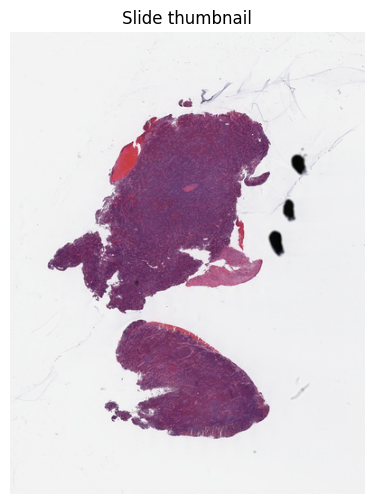

In [10]:
# Step 2 — Inspect one slide before tiling everything
import openslide
import matplotlib.pyplot as plt
import os

# Pick the first burkitt slide
burkitt_dir = f"{BASE_DIR}/slides/burkitt"
sample_slide_path = os.path.join(burkitt_dir, os.listdir(burkitt_dir)[0])

slide = openslide.OpenSlide(sample_slide_path)
#level 0= max zoom, number of pixels at max zoom is like dimension at level 0
print(f"Slide: {os.path.basename(sample_slide_path)}")
print(f"Dimensions (level 0): {slide.dimensions}")  # full resolution
#That's ~98,000 × 76,000 pixels — roughly 7.5 billion pixels total. This is why we can't load the whole thing into a ResNet
print(f"Number of zoom levels: {slide.level_count}")
print(f"Level dimensions: {slide.level_dimensions}")
print(f"Level downsamples: {slide.level_downsamples}")

#We need this number in the tiling code because openslide
#always wants coordinates expressed in level 0 pixels,
#even when you're reading from a lower resolution level.
# So we multiply our patch position by the downsample
# factor to convert coordinates correctly
# Show a low-res thumbnail to confirm it looks right
thumbnail = slide.get_thumbnail((512, 512))
plt.figure(figsize=(6, 6))
plt.imshow(thumbnail)
plt.title("Slide thumbnail")
plt.axis("off")
plt.show()

slide.close()

In [14]:
# Step 3 — Write the tiling function
import openslide
import numpy as np
from PIL import Image
import os
from tqdm import tqdm

PATCH_SIZE = 256        # pixels per patch
LEVEL = 1               # zoom level (0=full res, 1=quarter res, 2=1/8 res)
                        # level 1 is a good balance of detail vs speed
TISSUE_THRESHOLD = 0.7  # skip patches that are >70% background (white)
PATCHES_PER_SLIDE = 200 # max patches to extract per slide

def is_tissue(patch, threshold=TISSUE_THRESHOLD):
    """Return True if patch contains enough tissue (not mostly white background)."""
    gray = np.array(patch.convert("L"))  # convert to grayscale
    white_pixels = np.sum(gray > 220)    # count near-white pixels
    total_pixels = gray.size
    white_ratio = white_pixels / total_pixels
    return white_ratio < threshold       # True if not mostly white

def tile_slide(slide_path, output_dir, label, patches_per_slide=PATCHES_PER_SLIDE):
    """Extract tissue patches from a WSI and save as PNGs."""
    #we need to know which slide each patch came from
    slide_name = os.path.splitext(os.path.basename(slide_path))[0]
    os.makedirs(output_dir, exist_ok=True)

    # Check how many patches already exist for this slide (resume support)
    #So existing ends up as a list of all patches already extracted from this particular slide.
    existing = [f for f in os.listdir(output_dir) if f.startswith(slide_name)]
    if len(existing) >= patches_per_slide:
        print(f"  Already tiled: {slide_name} ({len(existing)} patches)")
        return len(existing)

    slide = openslide.OpenSlide(slide_path)

    # Use level 1 if available, otherwise fall back to level 0
    level = min(LEVEL, slide.level_count - 1)
    w, h = slide.level_dimensions[level]

    # Calculate how many tiles fit in each dimension
    cols = w // PATCH_SIZE
    rows = h // PATCH_SIZE

    saved = 0
    # Shuffle tile order so we get a spread across the slide
    positions = [(r, c) for r in range(rows) for c in range(cols)]
    np.random.shuffle(positions)

    for (row, col) in positions: #we only wanna pick around 200 patches
        if saved >= patches_per_slide:
            break

        # Calculate pixel coordinates at this level
        x = col * PATCH_SIZE
        y = row * PATCH_SIZE
        #so basically you get w and h, but in the level dimension, not in 0 dimension
        # Read the patch (openslide needs coords at level 0)
        scale = slide.level_downsamples[level]
        patch = slide.read_region(
            location=(int(x * scale), int(y * scale)),  #"start at this position, expressed in level 0 pixels"
            level=level, #"but read the actual image data from level 1"
            size=(PATCH_SIZE, PATCH_SIZE)  # "and give me a 256×256 patch"
        ).convert("RGB")

        # Skip background patches
        if not is_tissue(patch):
            continue

        # Save patch
        patch_name = f"{slide_name}_r{row:04d}_c{col:04d}.png"
        patch.save(os.path.join(output_dir, patch_name))
        saved += 1

    slide.close()
    return saved

In [17]:
# let's clean up the IHC patches in DLBCL
import os

patch_dir = f"{BASE_DIR}/patches/dlbcl"
all_patches = os.listdir(patch_dir)

# IHC slide name fragments to remove
ihc_markers = ["-CD3.", "-Ki67.", "-BCL6.", "-TP53.", "-BCL2."]

to_delete = [f for f in all_patches
             if any(marker in f for marker in ihc_markers)]

print(f"Total DLBCL patches before cleanup: {len(all_patches)}")
print(f"IHC patches to delete: {len(to_delete)}")

# Delete them
for fname in to_delete:
    os.remove(os.path.join(patch_dir, fname))

remaining = os.listdir(patch_dir)
print(f"Total DLBCL patches after cleanup: {len(remaining)}")

Total DLBCL patches before cleanup: 1000
IHC patches to delete: 1000
Total DLBCL patches after cleanup: 0


In [18]:
#step 4  Run tiling on all slides
import time

for label in ["burkitt", "dlbcl"]:
    slide_dir = f"{BASE_DIR}/slides/{label}"
    patch_dir = f"{BASE_DIR}/patches/{label}"

    # Filter to H&E slides only — filename contains "-HE" or "_HE"
    all_files = [f for f in os.listdir(slide_dir) if f.endswith(".svs")]
    he_files = [f for f in all_files if "-HE." in f or "_HE." in f]
    non_he = [f for f in all_files if f not in he_files]

    print(f"\n{label}: {len(all_files)} total slides")
    print(f"  H&E slides: {len(he_files)}")
    print(f"  Non-H&E skipped: {len(non_he)}")
    for f in non_he:
        print(f"    skipped: {f[:60]}")

    print(f"\nTiling {len(he_files)} H&E {label} slides...")
    total_patches = 0

    for i, fname in enumerate(he_files):
        slide_path = os.path.join(slide_dir, fname)
        print(f"  [{i+1}/{len(he_files)}] {fname[:60]}")

        # Skip unreadable files gracefully
        try:
            n = tile_slide(slide_path, patch_dir, label)
            total_patches += n
            print(f"    → {n} patches saved")
        except Exception as e:
            print(f"    ✗ Skipped — {e}")

        time.sleep(0.2)

    all_patches = [f for f in os.listdir(patch_dir) if f.endswith(".png")]
    print(f"\n{label} total: {len(all_patches)} patches in {patch_dir}")


burkitt: 20 total slides
  H&E slides: 20
  Non-H&E skipped: 0

Tiling 20 H&E burkitt slides...
  [1/20] BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963F-8B2CAFB0A6D3
  Already tiled: BLGSP-71-06-00288-01-HE.601C04C6-FA2C-4A4F-963F-8B2CAFB0A6D3 (200 patches)
    → 200 patches saved
  [2/20] BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4699-A4FB-93EB0
  Already tiled: BLGSP-71-06-00288-01A-01-S1-HE.41200E50-25AA-4699-A4FB-93EB0255B4B4 (237 patches)
    → 237 patches saved
  [3/20] BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-485F-A7EA-E9296
  Already tiled: BLGSP-71-06-00288-01A-01-S2-HE.AFFB745E-4910-485F-A7EA-E92964B51A03 (200 patches)
    → 200 patches saved
  [4/20] BLGSP-71-21-00188-01A-01-S1-HE.A7E17C68-DFC9-4573-BFD8-9D9FC
    → 158 patches saved
  [5/20] BLGSP-71-06-00098-01-HE.00FDE7CD-9A66-4979-ADE3-DBD87A793277
  Already tiled: BLGSP-71-06-00098-01-HE.00FDE7CD-9A66-4979-ADE3-DBD87A793277 (200 patches)
    → 200 patches saved
  [6/20] BLGSP-71-19-00105-01A-01-S1-HE.B8FA3D28-8F

In [19]:
import requests, json, pandas as pd

endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.disease_type", "value": "Mature B-Cell Lymphomas"}},
        {"op": "=", "content": {"field": "data_type", "value": "Slide Image"}},
        {"op": "=", "content": {"field": "data_format", "value": "SVS"}},
        {"op": "in", "content": {
            "field": "cases.project.project_id",
            "value": ["CGCI-HTMCP-DLBCL", "TCGA-DLBC"]
        }}
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id,file_name,file_size,cases.diagnoses.primary_diagnosis,cases.project.project_id",
    "format": "JSON",
    "size": 500
}

hits = requests.get(endpoint, params=params).json()["data"]["hits"]

rows = []
for h in hits:
    case = h.get("cases", [{}])[0]
    fname = h.get("file_name", "")
    # Check if H&E in filename
    is_he = "-HE." in fname or "_HE." in fname
    rows.append({
        "file_id": h["file_id"],
        "file_name": fname,
        "file_size_mb": round(h.get("file_size", 0) / 1e6, 1),
        "project": case.get("project", {}).get("project_id"),
        "diagnosis": case.get("diagnoses", [{}])[0].get("primary_diagnosis"),
        "is_he": is_he
    })

df = pd.DataFrame(rows)
print("All DLBCL SVS slides:")
print(df.groupby(["project", "is_he"]).size())
print(f"\nH&E only:")
he_df = df[df["is_he"]]
print(he_df.groupby("project").size())
print(f"\nSize range of H&E slides (MB): {he_df['file_size_mb'].min()} – {he_df['file_size_mb'].max()}")
print(f"Total H&E slides available: {len(he_df)}")

All DLBCL SVS slides:
project           is_he
CGCI-HTMCP-DLBCL  False    364
                  True      33
TCGA-DLBC         False    103
dtype: int64

H&E only:
project
CGCI-HTMCP-DLBCL    33
dtype: int64

Size range of H&E slides (MB): 41.3 – 1956.3
Total H&E slides available: 33


In [ ]:
#Let's check what the TCGA-DLBC filenames actually look like before we give up on them:

In [20]:
# Look at TCGA-DLBC filenames to understand their naming pattern
tcga_slides = df[df["project"] == "TCGA-DLBC"]
print("Sample TCGA-DLBC filenames:")
for fname in tcga_slides["file_name"].head(20).values:
    print(f"  {fname}")

Sample TCGA-DLBC filenames:
  TCGA-GS-A9TU-01Z-00-DX1.F10984B9-F06A-4729-B668-A5C184EE6D28.svs
  TCGA-FF-8047-01A-01-BS1.26a2166c-ed0c-4bac-9cc5-316219b3b7aa.svs
  TCGA-GS-A9TY-01A-01-TS1.11C3E54D-DCED-4F22-BA08-605A94A5D5EB.svs
  TCGA-FF-8047-01Z-00-DX1.75aa745c-bbe3-4869-a37b-c18ee50c14d5.svs
  TCGA-FF-8047-01A-01-TS1.b9b7d82b-14a3-45a5-954f-1e8c9457a12e.svs
  TCGA-FA-A86F-01Z-00-DX1.EE36DC3F-7539-41E8-ADF6-6BA0FB0F47C4.svs
  TCGA-GS-A9TZ-01A-01-TSA.686AE713-E246-41CE-8114-072488F96494.svs
  TCGA-GS-A9U3-01A-01-TS1.F04D39B6-782C-4903-91E7-1C1EC47F2687.svs
  TCGA-G8-6906-01Z-00-DX1.61bfad6c-4e24-414f-9bcf-18ce30d6a75e.svs
  TCGA-G8-6906-01A-01-BS1.dea2d8e9-4a29-4783-9165-a7ed5e6133d2.svs
  TCGA-GS-A9TU-01A-01-TS1.09D04254-6DCC-4AD9-8AF5-6C14C994F6D6.svs
  TCGA-FF-8041-01A-01-BS1.8303a79f-1679-434b-8a46-0cca125e4791.svs
  TCGA-FF-8041-01Z-00-DX1.b9ba3fca-9adc-43d2-8439-7231a5be67a9.svs
  TCGA-G8-6906-01A-01-TS1.0956f1f3-0b2d-4f3f-8efd-934a41704f37.svs
  TCGA-FF-8041-01A-01-TS1.b8b69ce3

TCGA-DLBC slides are all H&E but use a completely different naming convention. Instead of "-HE." they use letter codes embedded in the filename:

DX = DiX (diagnostic slide)


BS = Bottom Slide


TS = Top Slide


TSA = Top Slide A

These are all standard H&E histology slides — TCGA simply never bothered labeling them with "-HE." because the entire TCGA-DLBC collection is H&E only, unlike CGCI-HTMCP-DLBCL which mixes H&E with IHC.

In [21]:
def get_dlbcl_he_slides(max_size_mb=500, n=20):
    filters = {
        "op": "and",
        "content": [
            {"op": "=", "content": {"field": "cases.disease_type", "value": "Mature B-Cell Lymphomas"}},
            {"op": "=", "content": {"field": "data_type", "value": "Slide Image"}},
            {"op": "=", "content": {"field": "data_format", "value": "SVS"}},
            {"op": "in", "content": {
                "field": "cases.project.project_id",
                "value": ["CGCI-HTMCP-DLBCL", "TCGA-DLBC"]
            }},
            {"op": "in", "content": {
                "field": "cases.diagnoses.primary_diagnosis",
                "value": [
                    "Diffuse large B-cell lymphoma, NOS",
                    "Mediastinal (thymic) large B-cell lymphoma"
                ]
            }}
        ]
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,file_name,file_size,cases.project.project_id",
        "format": "JSON",
        "size": 500
    }
    hits = requests.get(endpoint, params=params).json()["data"]["hits"]

    rows = []
    for h in hits:
        fname = h.get("file_name", "")
        size_mb = round(h.get("file_size", 0) / 1e6, 1)
        project = h.get("cases", [{}])[0].get("project", {}).get("project_id")

        # H&E filter — CGCI uses "-HE.", TCGA is all H&E
        is_he = "-HE." in fname or "_HE." in fname or project == "TCGA-DLBC"

        if is_he and size_mb <= max_size_mb:
            rows.append({
                "file_id": h["file_id"],
                "file_name": fname,
                "file_size_mb": size_mb,
                "project": project,
                "label": "dlbcl"
            })
        if len(rows) == n:
            break

    return rows

# Get 20 new DLBCL H&E slides (we already have 2 downloaded, get 18 more)
new_dlbcl = get_dlbcl_he_slides(max_size_mb=500, n=20)
new_manifest = pd.DataFrame(new_dlbcl)

print(f"New DLBCL H&E slides found: {len(new_manifest)}")
print(f"\nBreakdown by project:")
print(new_manifest["project"].value_counts())
print(f"\nSize range (MB): {new_manifest['file_size_mb'].min()} – {new_manifest['file_size_mb'].max()}")
print(f"Total estimated download size: {new_manifest['file_size_mb'].sum():.0f} MB")

# Save new manifest
new_manifest.to_csv(f"{BASE_DIR}/manifest_dlbcl_new.csv", index=False)
display(new_manifest.head(10))

New DLBCL H&E slides found: 20

Breakdown by project:
project
TCGA-DLBC    20
Name: count, dtype: int64

Size range (MB): 44.1 – 390.8
Total estimated download size: 4095 MB


,file_id,file_name,file_size_mb,project,label
0,350e86fe-3b45-4503-8f0d-a39269e1864e,TCGA-FF-8047-01A-01-BS1.26a2166c-ed0c-4bac-9cc...,180.5,TCGA-DLBC,dlbcl
1,4ad5bb7a-626a-4e32-9560-f2c12930e52d,TCGA-GS-A9TY-01A-01-TS1.11C3E54D-DCED-4F22-BA0...,390.8,TCGA-DLBC,dlbcl
2,0609ae18-458a-4971-938e-1942e35c11b2,TCGA-FF-8047-01Z-00-DX1.75aa745c-bbe3-4869-a37...,291.5,TCGA-DLBC,dlbcl
3,bad9afb2-fbde-49a0-b05f-ac0fc6b7b57c,TCGA-FF-8047-01A-01-TS1.b9b7d82b-14a3-45a5-954...,134.2,TCGA-DLBC,dlbcl
4,233e0ac3-e8a6-4132-b4cd-68ddcd3890bd,TCGA-GS-A9TZ-01A-01-TSA.686AE713-E246-41CE-811...,219.5,TCGA-DLBC,dlbcl
5,1bf116f8-d991-4ca9-b7db-c3c644554335,TCGA-G8-6906-01A-01-BS1.dea2d8e9-4a29-4783-916...,106.4,TCGA-DLBC,dlbcl
6,e57f7b6e-3542-471b-a404-4fa5cab0e236,TCGA-GS-A9TU-01A-01-TS1.09D04254-6DCC-4AD9-8AF...,335.6,TCGA-DLBC,dlbcl
7,90de71cc-b876-4231-9af9-879ca9903a45,TCGA-FF-8041-01A-01-BS1.8303a79f-1679-434b-8a4...,87.6,TCGA-DLBC,dlbcl
8,d1db7ff6-a18b-448a-8e97-d9b7e75cd930,TCGA-FF-8041-01Z-00-DX1.b9ba3fca-9adc-43d2-843...,220.2,TCGA-DLBC,dlbcl
9,93c5aa32-ea4f-46a1-8488-3016cba31155,TCGA-G8-6906-01A-01-TS1.0956f1f3-0b2d-4f3f-8ef...,66.4,TCGA-DLBC,dlbcl
